## Import libraries

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud


## loading processed data

In [7]:
import sys
import os

project_path = os.path.abspath("..") 
sys.path.append(project_path)

from src.data.preprocessor import processed_data
filepath = "../data/twitter.csv"

df = processed_data(filepath)


Loading data...
Cleaning text...
Removing nulls, empty values, and duplicates...
Saving dataset...
Cleaned dataset saved as processed.csv


In [8]:
df.head()

,cleaned_text,target
0,awww thats bummer shoulda got david carr third...,0
1,upset cant update facebook texting might cry r...,0
2,dived many times ball managed save rest go bounds,0
3,whole body feels itchy like fire,0
4,not behaving im mad cant see,0


In [9]:
df.shape

(1482190, 2)

In [10]:
df.info

<bound method DataFrame.info of                                               cleaned_text  target
0        awww thats bummer shoulda got david carr third...       0
1        upset cant update facebook texting might cry r...       0
2        dived many times ball managed save rest go bounds       0
3                         whole body feels itchy like fire       0
4                             not behaving im mad cant see       0
...                                                    ...     ...
1599995                      woke school best feeling ever       1
1599996            thewdbcom cool hear old walt interviews       1
1599997                    ready mojo makeover ask details       1
1599998  happy th birthday boo alll time tupac amaru sh...       1
1599999                               happy charitytuesday       1

[1482190 rows x 2 columns]>

In [11]:
df.isnull().sum()

cleaned_text    0
target          0
dtype: int64

## Statistics

In [12]:
df['n_char'] = df['cleaned_text'].apply(len)
df['n_word'] = df['cleaned_text'].apply(lambda x :len(x.split()))
df["avg_word_len"] = df["cleaned_text"].apply(
    lambda x: sum(len(word) for word in x.split()) / len(x.split()) 
    if len(x.split()) > 0 
    else 0
)

In [13]:
df.head()

,cleaned_text,target,n_char,n_word,avg_word_len
0,awww thats bummer shoulda got david carr third...,0,50,9,4.666667
1,upset cant update facebook texting might cry r...,0,74,12,5.250000
2,dived many times ball managed save rest go bounds,0,49,9,4.555556
3,whole body feels itchy like fire,0,32,6,4.500000
4,not behaving im mad cant see,0,28,6,3.833333


In [14]:
df.describe()

,target,n_char,n_word,avg_word_len
count,1.482190e+06,1.482190e+06,1.482190e+06,1.482190e+06
mean,4.942187e-01,4.512373e+01,7.542339e+00,5.188903e+00
std,4.999667e-01,2.306434e+01,3.769890e+00,1.120005e+00
min,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,0.000000e+00,2.600000e+01,4.000000e+00,4.500000e+00
50%,0.000000e+00,4.200000e+01,7.000000e+00,5.000000e+00
75%,1.000000e+00,6.200000e+01,1.000000e+01,5.687500e+00
max,1.000000e+00,1.360000e+02,3.500000e+01,1.250000e+02


In [15]:
words = " ".join(df['cleaned_text']).split()
word_freq = Counter(words)

In [16]:
common_words = word_freq.most_common(50)
words = [word[0] for word in common_words]
counts = [word[1] for word in common_words]
set = {
    "common_words" : words,
    "freq" : counts
}
print(pd.DataFrame(set))


   common_words    freq
0            im  174846
1           not  103225
2          good   82834
3           day   80188
4           get   79101
5          like   76197
6            go   71068
7          dont   65357
8         today   63031
9         going   62465
10         love   61080
11         cant   60837
12          got   59560
13         work   59062
14         time   55143
15         back   54188
16          lol   54147
17            u   52146
18          one   51385
19         know   49265
20       really   48321
21          see   44689
22         well   43380
23        still   41961
24          new   41141
25        night   40396
26        think   40313
27         want   40269
28         home   37231
29           oh   37081
30         much   35480
31         last   34753
32         need   34682
33         miss   33660
34       thanks   33175
35         hope   32110
36     tomorrow   32019
37        great   31880
38          ill   31320
39      morning   30182
40         haha 

In [17]:
df.groupby("target")["n_word"].mean()

target
0    7.746324
1    7.333583
Name: n_word, dtype: float64

In [18]:
df.groupby("target")["n_word"].count()

target
0    749664
1    732526
Name: n_word, dtype: int64

In [19]:
words_0 = df[df['target'] == 0]['cleaned_text']
all_words_0 = " ".join(words_0).split()
common_words_0 = Counter(all_words_0).most_common(50)

w_0 = [word[0] for word in common_words_0]
c_0 = [word[1] for word in common_words_0]

set_0 = {
    "common words for class 0" : w_0 ,
    "freq" : c_0
}
print(pd.DataFrame(set_0))

   common words for class 0    freq
0                        im  100834
1                       not   71058
2                       get   44897
3                        go   43815
4                      dont   43511
5                      cant   42294
6                      work   40883
7                      like   40144
8                       day   38436
9                     today   35403
10                    going   32767
11                      got   32527
12                     back   31569
13                   really   30351
14                     want   28344
15                     miss   28319
16                    still   28105
17                     good   27178
18                     time   26497
19                      one   26073
20                      sad   25947
21                     know   24759
22                     home   22477
23                        u   22452
24                     last   21908
25                      lol   21521
26                     need 

In [20]:
words_1 = df[df['target'] == 1]['cleaned_text']
all_words_1 = " ".join(words_1).split()
common_words_1 = Counter(all_words_1).most_common(50)

w_1 = [word[0] for word in common_words_1]
c_1 = [word[1] for word in common_words_1]

set_1 = {
    "common words for class 1" : w_1 ,
    "freq" : c_1
}
print(pd.DataFrame(set_1))

   common words for class 1   freq
0                        im  74012
1                      good  55656
2                      love  44760
3                       day  41752
4                      like  36053
5                       get  34204
6                       lol  32626
7                       not  32167
8                     going  29698
9                         u  29694
10                     time  28646
11                   thanks  27677
12                    today  27628
13                       go  27253
14                      got  27033
15                      new  25903
16                      one  25312
17                      see  24777
18                     know  24506
19                     well  24054
20                    great  24016
21                     back  22619
22                     dont  21846
23                    night  21370
24                     haha  20253
25                    think  18962
26                     cant  18543
27                  

## Visualization

 ### Character Count Distribution

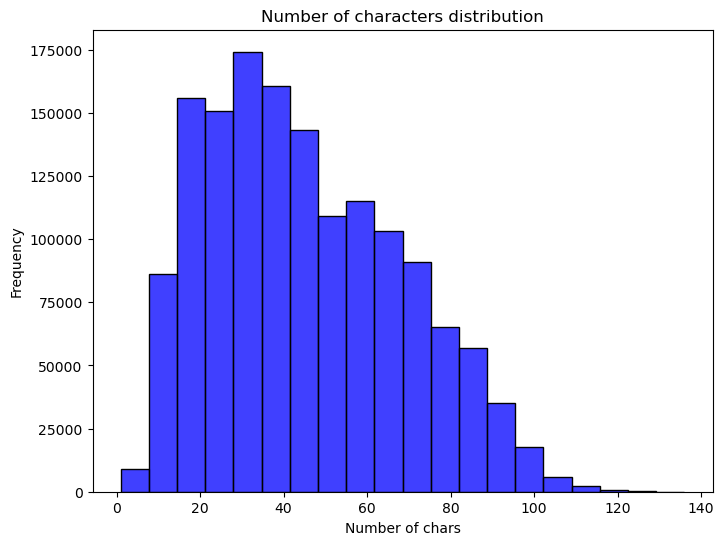

In [21]:
plt.figure(figsize=(8,6))
sns.histplot(df['n_char'] , bins=20 , color = 'blue' )
plt.title("Number of characters distribution")
plt.xlabel("Number of chars")
plt.ylabel("Frequency")
plt.savefig("../results/figures/char_distribution.png", bbox_inches="tight")
plt.show()

### Word Count Distribution

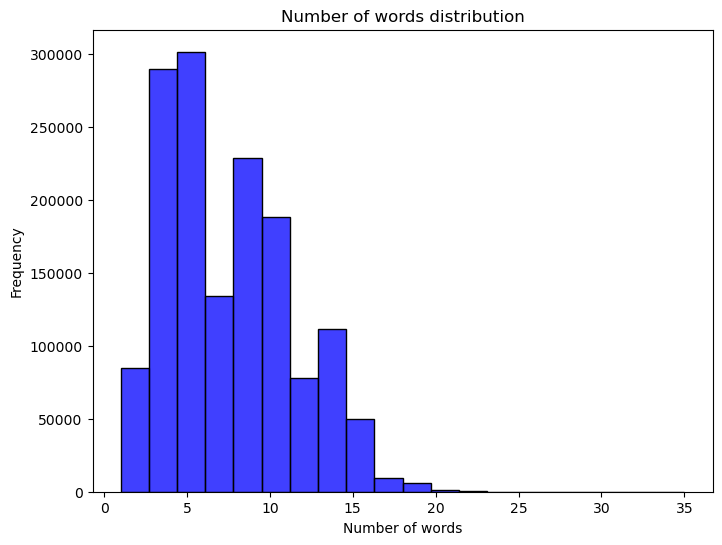

In [22]:
plt.figure(figsize=(8,6))
sns.histplot(df['n_word'] , bins=20 , color='blue' )
plt.title("Number of words distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.savefig("../results/figures/word_distribution.png", bbox_inches="tight")
plt.show()

### Target Distribution

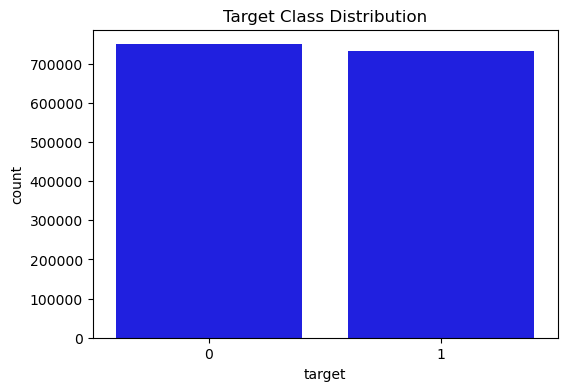

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df , color='blue')
plt.title("Target Class Distribution")
plt.savefig("../results/figures/target_distribution.png", bbox_inches="tight")

plt.show()

### Plot Most Frequent Words

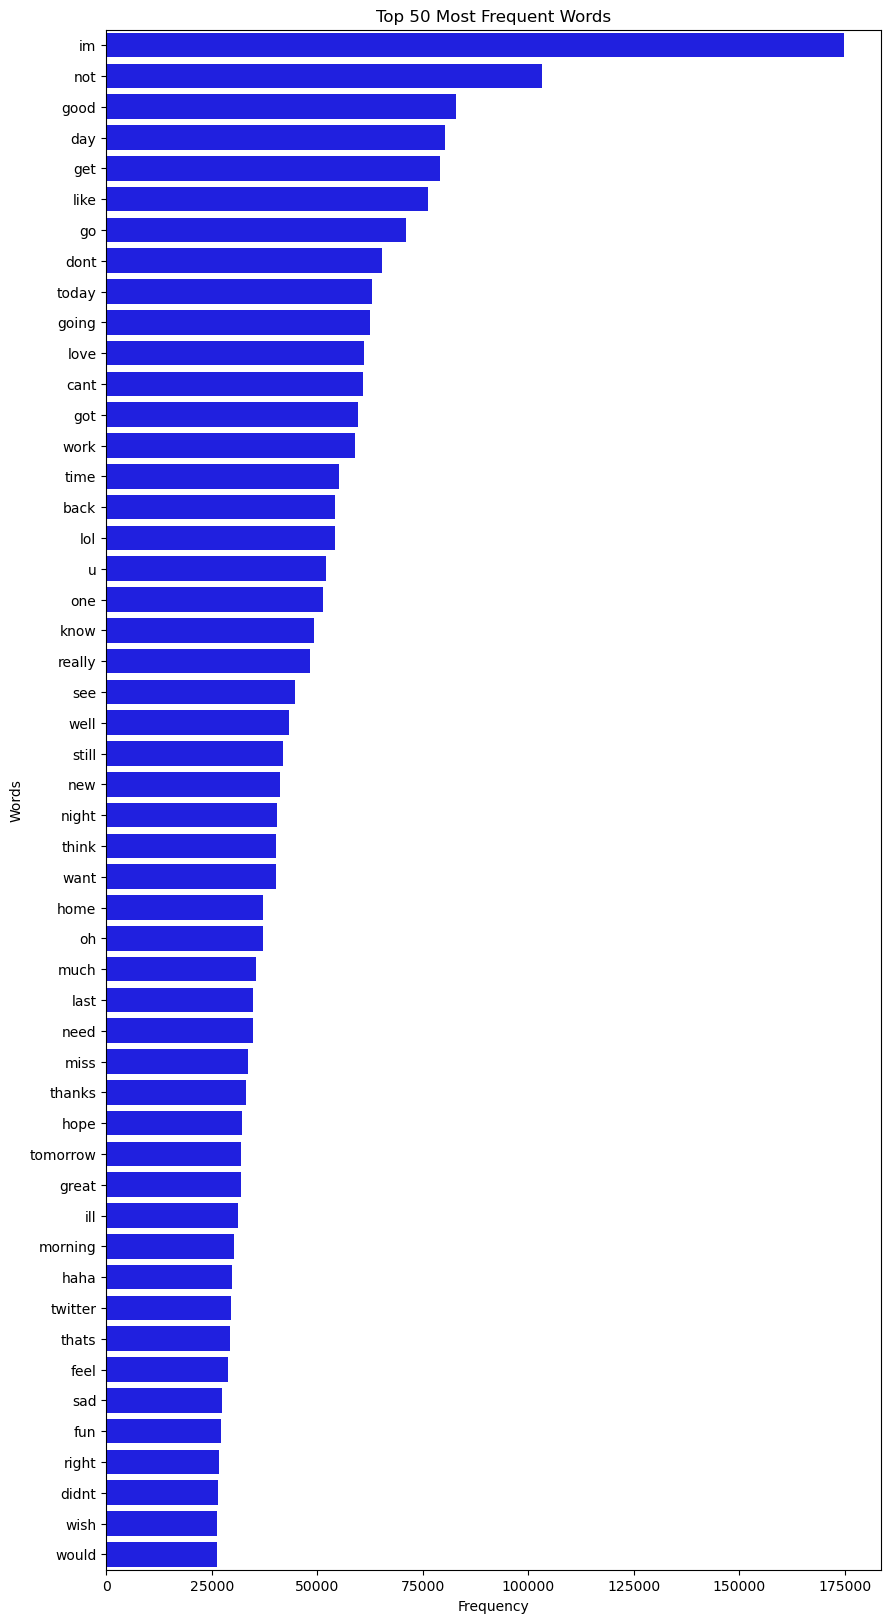

In [24]:
plt.figure(figsize=(10,20))

sns.barplot(x=counts, y=words , color = 'blue')

plt.title("Top 50 Most Frequent Words")

plt.xlabel("Frequency")
plt.ylabel("Words")
plt.savefig("../results/figures/word_frequency.png", bbox_inches="tight")

plt.show()

### Word Cloud Visualization

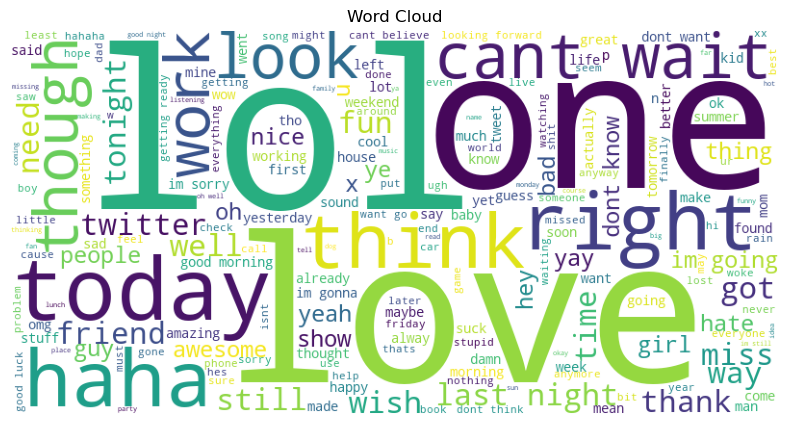

In [25]:
text = " ".join(df["cleaned_text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Word Cloud")
plt.savefig("../results/figures/wordcloud.png", bbox_inches="tight")

plt.show()

### Common words in class 0

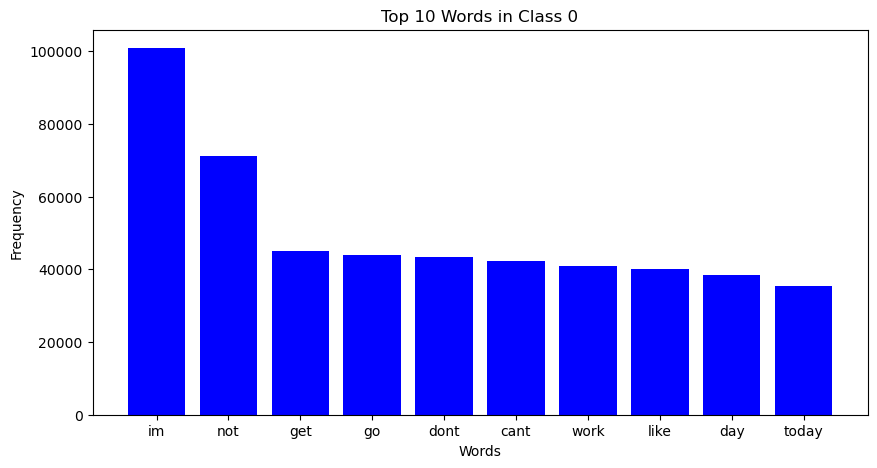

In [26]:
plt.figure(figsize=(10, 5))
plt.bar(w_0[:10], c_0[:10], color='blue')
plt.title("Top 10 Words in Class 0")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.savefig("../results/figures/common_words_class0.png", bbox_inches="tight")

plt.show()

### Common words in class 1

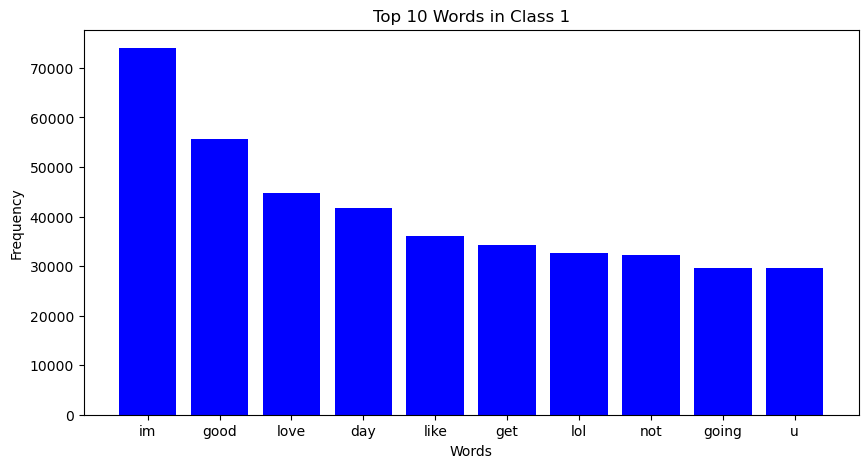

In [27]:
plt.figure(figsize=(10, 5))
plt.bar(w_1[:10], c_1[:10], color='blue')
plt.title("Top 10 Words in Class 1")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.savefig("../results/figures/common_words_class1.png", bbox_inches="tight")

plt.show()